In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import os

sys.path.insert(0, '../scripts/')

from importlib import reload

import small_utilities
reload(small_utilities)
import Block_analysis
reload(Block_analysis)

from Block_analysis import *
from small_utilities import *

import seaborn as sns
from collections import OrderedDict


## Analysis for $\alpha$-synuclien Apo (Trajectory-1)

In this notebook we will analize the Meta dynamics trajectories of $\alpha$-synuclien protein only trajectories.

### Loading the data

The colvar files are generated from the concatinated trajectories at the respective time intervels. For example, $100ns$ for each replica trajectory is obtained and concatinated togeather, which is used to compute the weights. 

In [2]:
# work_directory = os.getcwd()
work_directory = '/data/ssREST3/Apo/PBMetaD-1/'
a = np.sort([i for i in os.listdir(work_directory) if os.path.isdir(f'{work_directory}/{i}')])

print(f'Current working dir: \n{work_directory}\n')
print(f'which has the following directories: \n{a}')
print(os.getcwd())

Current working dir: 
/data/ssREST3/Apo/PBMetaD-1/

which has the following directories: 
['colvar' 'data']
/data/ssREST3/Apo


In [3]:
colvar_data={}
weights_norm={}

last_time=2000

for i in range(0,2000, 100):

    if i==0:
        colvar_data[i+last_time]=np.loadtxt(f'{work_directory}/{a[0]}/colvar_{i}.dat', comments=['#','@'])
        num_cvs, _, weights_norm[i+last_time] = norm_weights(f'{work_directory}/{a[0]}/colvar_{i}.dat')
        print(f"Sum of combined xtc weights : {np.sum(weights_norm[i+last_time])}")
        print(f"Number of frames : {colvar_data[i+last_time].shape[0]}")
    else:
            
        colvar_data[i]=np.loadtxt(f'{work_directory}/{a[0]}/colvar_{i}.dat', comments=['#','@'])
        num_cvs, _, weights_norm[i] = norm_weights(f'{work_directory}/{a[0]}/colvar_{i}.dat')

        print(f"Sum of combined xtc weights : {np.sum(weights_norm[i])}")
        print(f"Number of frames : {colvar_data[i].shape[0]}")
    


Sum of combined xtc weights : 1.0000000000000016
Number of frames : 3200001
Sum of combined xtc weights : 1.0
Number of frames : 160001
Sum of combined xtc weights : 0.9999999999999996
Number of frames : 320001
Sum of combined xtc weights : 1.0
Number of frames : 480001
Sum of combined xtc weights : 0.9999999999999999
Number of frames : 640001
Sum of combined xtc weights : 1.0000000000000004
Number of frames : 800001
Sum of combined xtc weights : 0.9999999999999993
Number of frames : 960001
Sum of combined xtc weights : 1.0000000000000004
Number of frames : 1120001
Sum of combined xtc weights : 1.0000000000000007
Number of frames : 1280001
Sum of combined xtc weights : 1.0000000000000004
Number of frames : 1440001
Sum of combined xtc weights : 1.0000000000000002
Number of frames : 1600001
Sum of combined xtc weights : 0.9999999999999991
Number of frames : 1760001
Sum of combined xtc weights : 0.9999999999999999
Number of frames : 1920001
Sum of combined xtc weights : 1.0000000000000002

### Plot for 100ns data (3200ns(3.2 $\mu$ s) aggregate time.)

By changing the `index` we will plot the CV's of respective aggregate time.

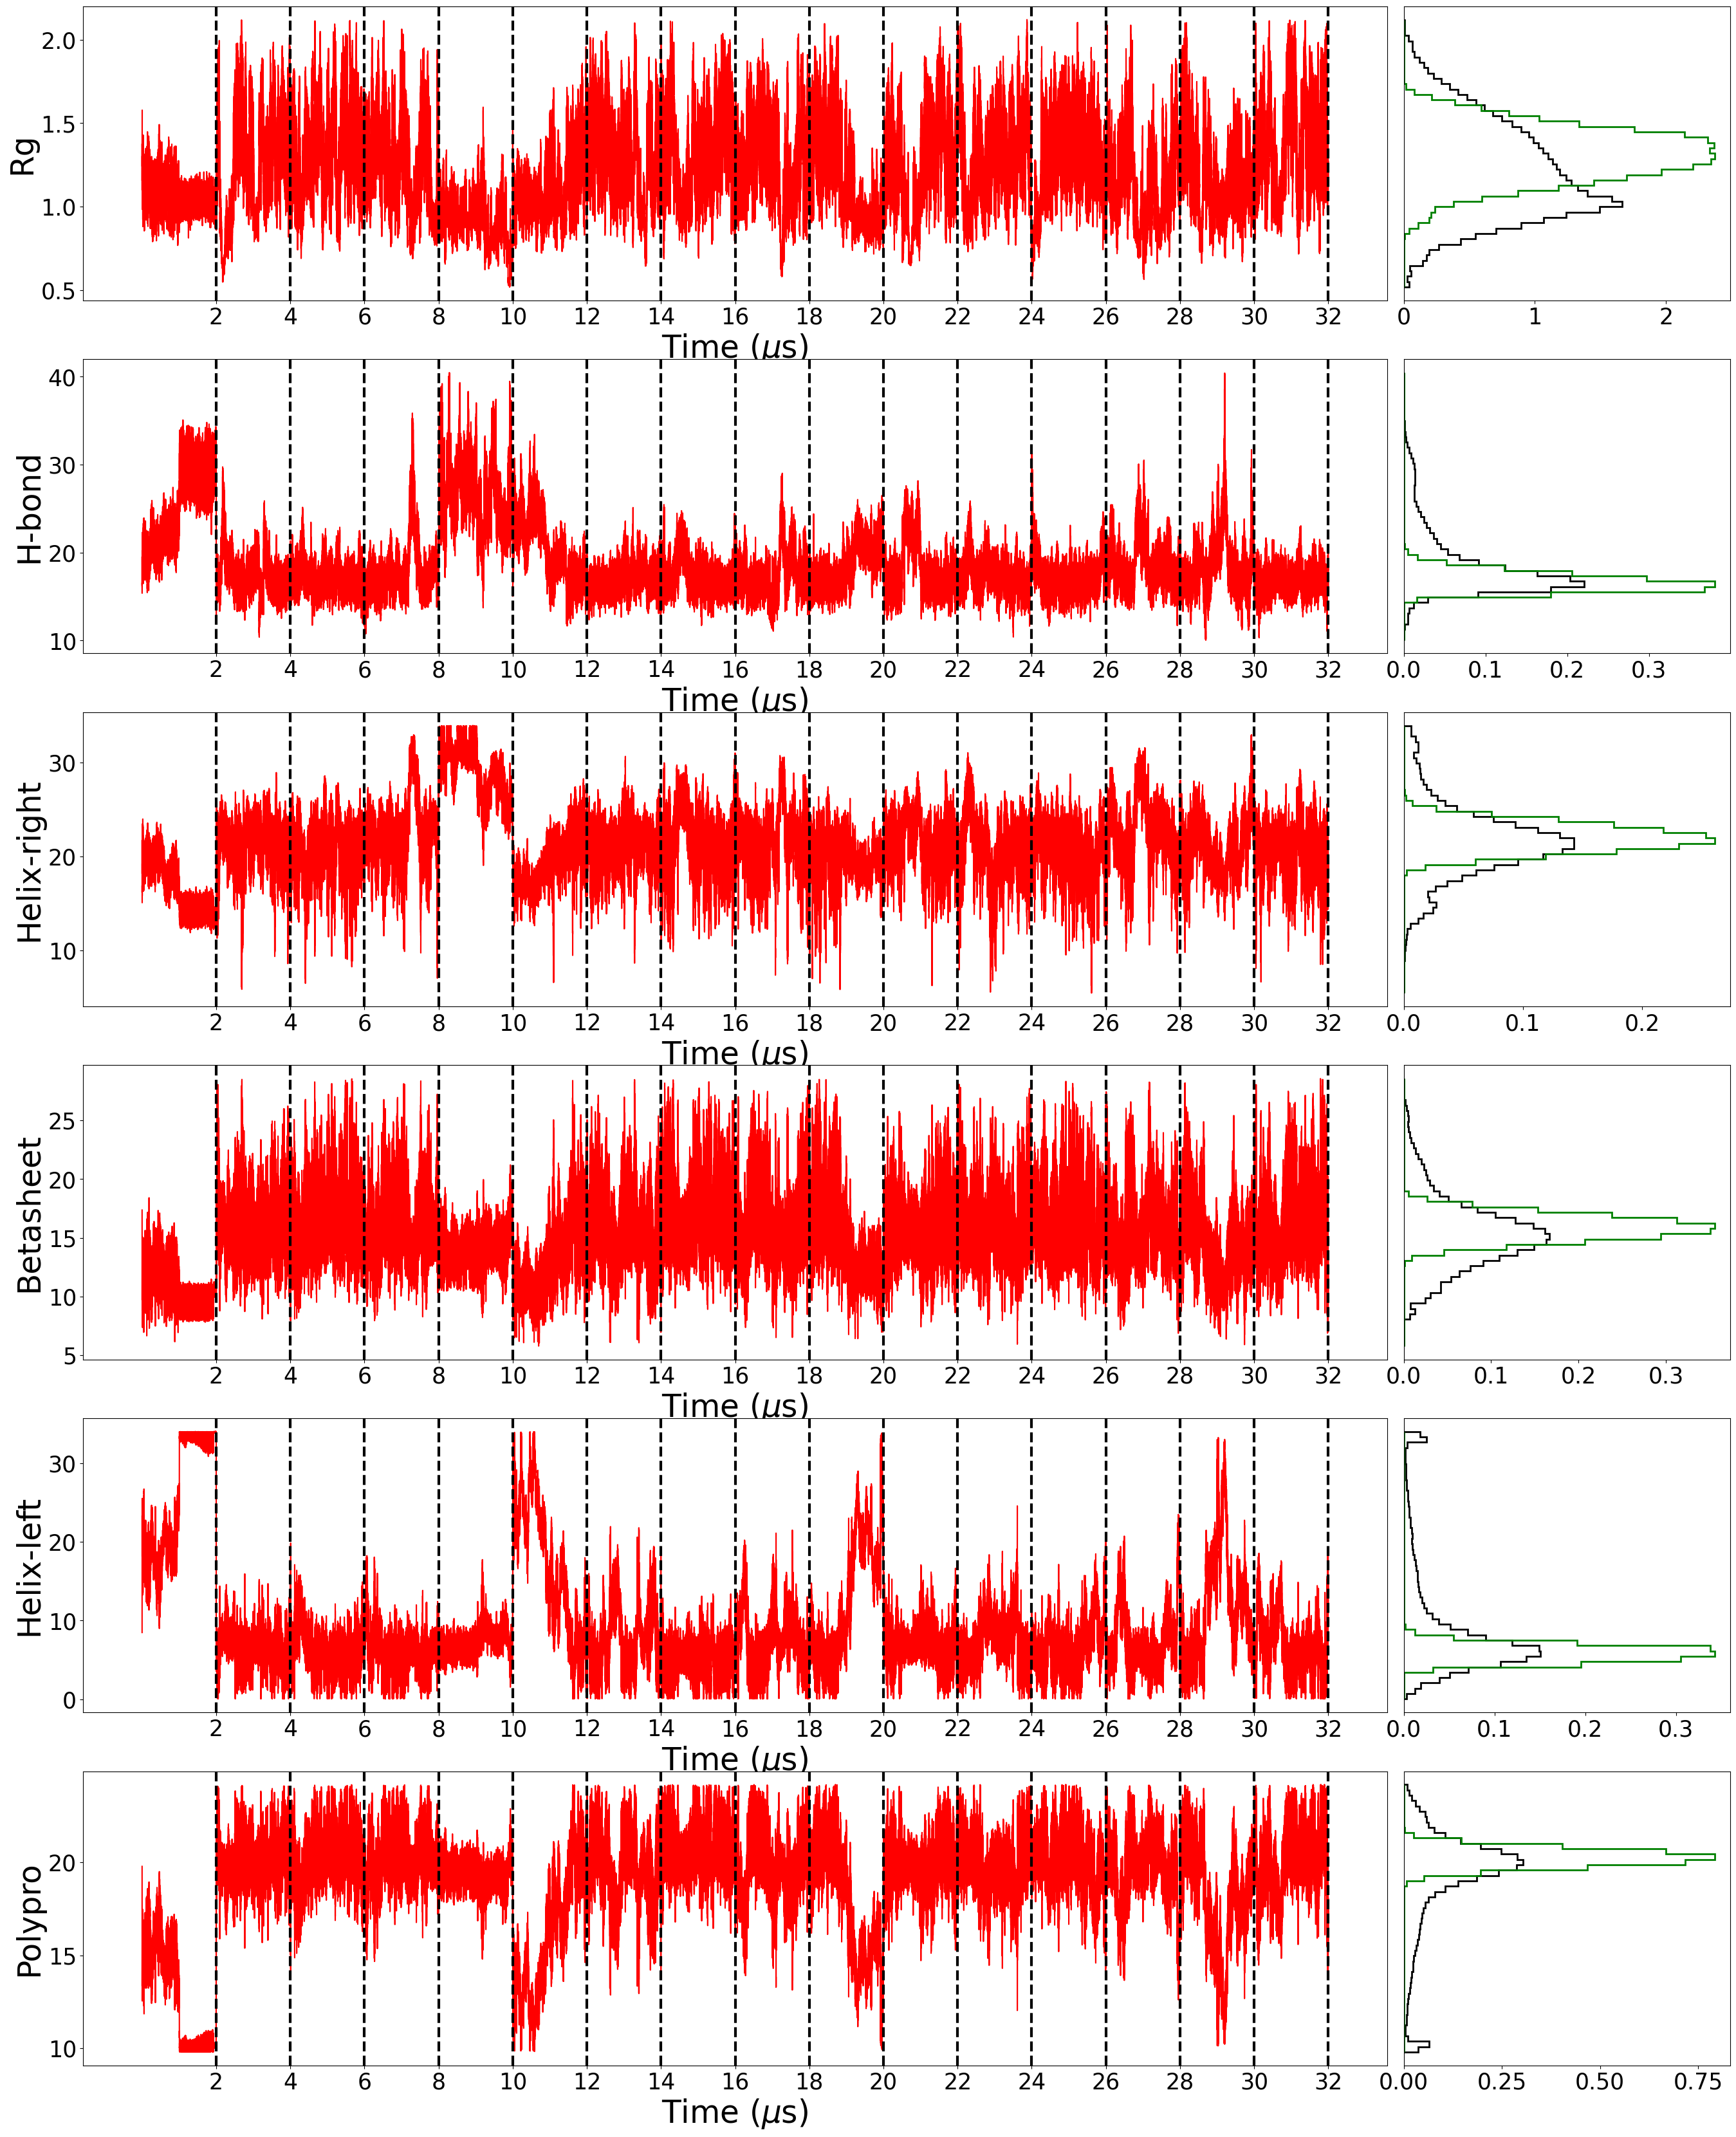

In [4]:
label={
    '1':'Rg', '2':'H-bond', '3':'Helix-right', '4':'Betasheet', '5':'Helix-left', '6':'Polypro',
       }

# change the value of index from 100 to 1000 to see the plot for the different aggregate data
index=2000
trj_frames=create_trj_frames(colvar_data[index])

plot_colvar(colvar_data[index], trj_frames, num_cvs, labels=label, weights=weights_norm[index])

### Free energy plot of Rg computed plotted from the respective colver files

In [5]:
index_dict={
    'Rg':1, 'H-bond':2, 'Helix-right':3, 'Betasheet':4, 'Helix-left':5, 'Polypro':6
       }

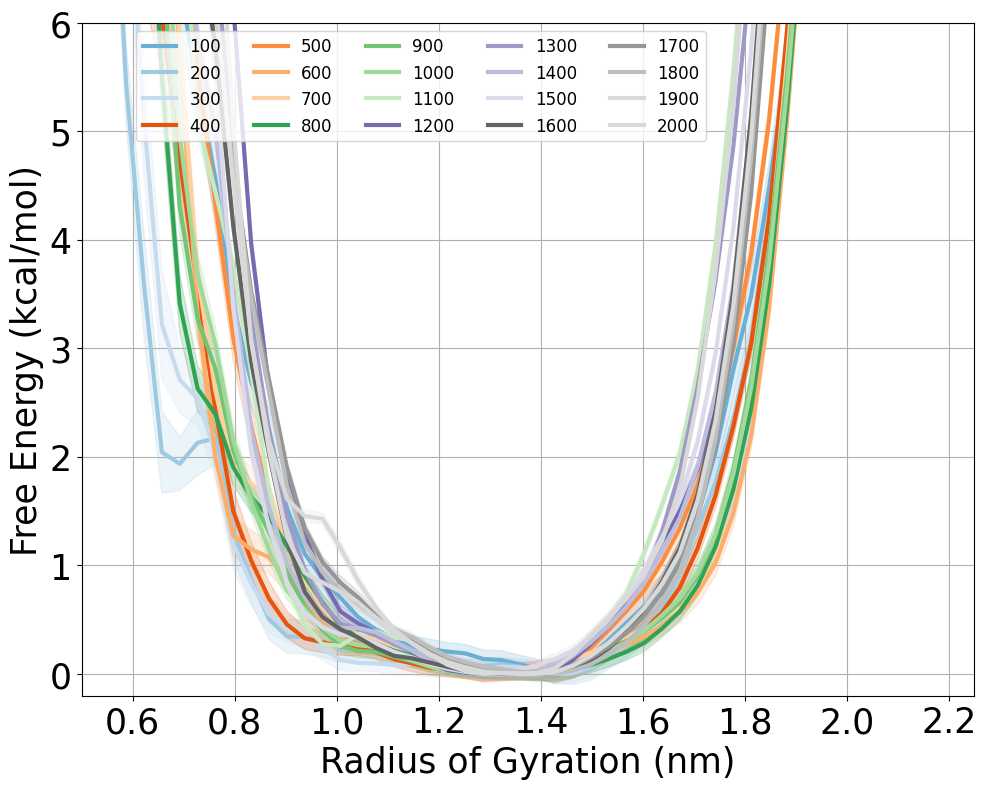

In [6]:
np.seterr(invalid='ignore')

plt.figure(figsize=(10,8))

for i in range(100,2100, 100):
    dG1, bin_centers, ferr = free_energy_1D_blockerror(colvar_data[i].T[index_dict['Rg']], T=300, x0=0.5, xmax=2.25, bins=50, blocks_no=None, weights=weights_norm[i])

    sns.lineplot(x=bin_centers, y=dG1, color=plt.cm.tab20c(int(i/100)), linewidth=3,label=str(i), linestyle='-')
    plt.fill_between(bin_centers, dG1-ferr, dG1+ferr, color=plt.cm.tab20c(int(i/100)), alpha=0.2)

plt.ylim(-0.2, 6)
plt.xlim(0.5, 2.25)
plt.xlabel('Radius of Gyration (nm)', size=25)
plt.ylabel('Free Energy (kcal/mol)', size=25)
plt.legend(loc='upper center', fontsize=12, ncol=5, bbox_to_anchor=(0.38, 1.0))
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
#plt.title(f"Replica : {val}", size=20)
plt.tight_layout()
plt.grid()
plt.show()

In [7]:
mean_rg=np.zeros((20,2))
# mean_rg_err=np.zeros(10)

for i in range(100,2100, 100):
    # print(f'{i} : {get_blockerror_pyblock_nanskip_rw_(colvar_data[i].T[1], weights_norm[i])}')
    mean_rg[int(i/100)-1]=get_blockerror_pyblock_nanskip_rw_(colvar_data[i].T[index_dict['Rg']], weights_norm[i])

mean_rg

array([[1.32141921, 0.02355498],
       [1.26369254, 0.0400952 ],
       [1.26995814, 0.02875531],
       [1.27193438, 0.02560673],
       [1.27224024, 0.017711  ],
       [1.30548402, 0.01923026],
       [1.31597655, 0.01530382],
       [1.3265228 , 0.01671791],
       [1.29956537, 0.01507043],
       [1.29955364, 0.01327326],
       [1.26073647, 0.01224225],
       [1.2977325 , 0.00894411],
       [1.28489637, 0.00821844],
       [1.27918727, 0.00931975],
       [1.25884312, 0.0095874 ],
       [1.29634637, 0.00800091],
       [1.335088  , 0.00669119],
       [1.34059857, 0.00848668],
       [1.31949449, 0.0075726 ],
       [1.31194936, 0.00569752]])

### $<Rg>$ plotted against aggregate time

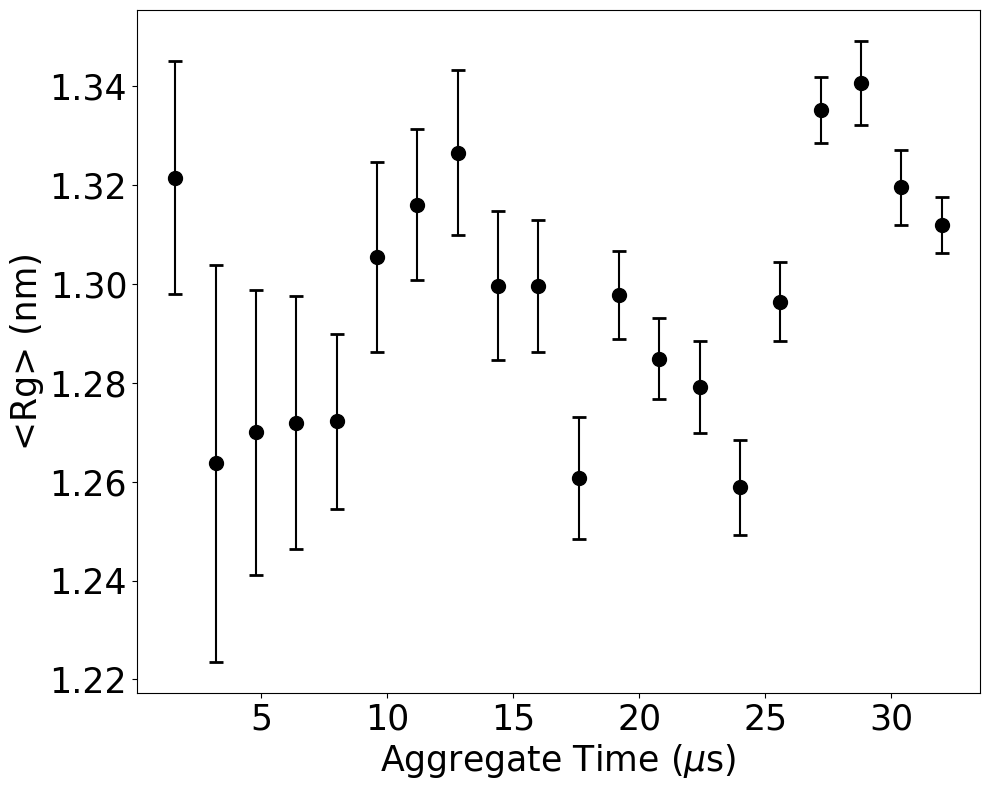

In [8]:
plt.figure(figsize=(10,8))

plt.errorbar(np.arange(0.1,2.1,0.1)*16, mean_rg.T[0], yerr=mean_rg.T[1], fmt='o', color='black', markersize=10, capsize=5, capthick=2)

plt.tick_params(labelsize=25)
plt.xlabel(r'Aggregate Time ($\mu$s)', size=25)
plt.ylabel(r'<Rg> (nm)', size=25)
plt.tight_layout()